# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [16]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [17]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [18]:
usage.head

<bound method NDFrame.head of           id  user_id  type                           date  duration  length
0          1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1          2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2          3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3          4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4          5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN
...      ...      ...   ...                            ...       ...     ...
39995  39996    13497  call  2024-06-29 23:33:56.120903022      5.75     NaN
39996  39997    10941  call  2024-06-29 23:40:27.090677266      3.06     NaN
39997  39998    13038  call  2024-06-29 23:46:58.060451510      8.74     NaN
39998  39999    10863  text  2024-06-29 23:53:29.030225754       NaN    43.0
39999  40000    10759  call  2024-06-30 00:00:00.000000000      1.32     NaN

[40000 rows x 6 columns]>

**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [19]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", ...)
print("usage", ...)

plans (2, 8)
users Ellipsis
usage Ellipsis


In [20]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [10]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [21]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [22]:
# cantidad de nulos para users
print(users.isna().sum())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [23]:
print(usage.isna().sum())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


**Comentarios Juliana** 
**USERS**
- city: Tiene 469 valores nulos (≈11.7%), lo que indica información de ciudad faltante que podría requerir revisión o tratamiento.

- churn_date: Tiene 3534 valores nulos (≈88.35%), lo cual es esperado porque los valores nulos representan usuarios que aún no han cancelado el servicio.

**USAGE**
- La columna date tiene muy pocos nulos (≈0.13%), mientras que duration (≈55.2%) y length (≈44.7%) presentan muchos nulos porque se registran según el tipo de uso: duration para llamadas y length para mensajes, por lo que los nulos son esperados.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [24]:
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


**Comentarios Juliana** 
- user_id: La columna funciona como identificador único de los usuarios, contiene 4000 registros sin valores faltantes y no presenta problemas aparentes. La desviacion estandar no es confiable por que el -999 distorsiona el cálculo. 
- age: Se observa un valor mínimo de -999, lo cual no es una edad válida y probablemente representa un valor usado para indicar datos faltantes que debería reemplazarse por NaN para el análisis.

In [25]:
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


**Comentarios Juliana**
- id: La columna contiene identificadores únicos para cada registro, sin valores nulos y con una secuencia consistente de 1 a 40000, por lo que no presenta problemas.

- user_id: La columna representa los usuarios asociados a cada registro, con valores dentro del rango esperado (10000–13999) y sin valores nulos, por lo que no muestra inconsistencias.

In [26]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']]
columnas_user.head()

,city,plan
0,Medellín,Basico
1,?,Basico
2,CDMX,Basico
3,Bogotá,Premium
4,GDL,Basico


**Comentarios Juliana**
- city: Presenta valores inconsistentes como "?", lo que indica datos faltantes o mal registrados, por lo que requiere limpieza o tratamiento.
- plan: Contiene categorías claras (como Básico y Premium) sin inconsistencias aparentes.

In [27]:
# explorar columna categórica de usage
columnas_usage= usage ['type']
columnas_usage.head()

0    call
1    text
2    text
3    call
4    call
Name: type, dtype: object

**Comentarios Juliana**
- type: Contiene dos categorías claras (call y text) que representan los tipos de uso, sin valores nulos ni inconsistencias aparentes.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- **¿En qué columnas encontraste valores inválidos o sentinels?**
Se identificaron valores inválidos o sentinels en la columna age de users, donde aparece -999 como edad no válida, y en la columna city de users, donde aparece "?" como valor inconsistente o dato faltante.
- **¿Qué acción tomarías?**
En ambos casos, reemplazaría -999 y "?" por NaN, ya que representan datos faltantes o mal registrados, y luego evaluaría si conviene imputarlos o excluirlos según el análisis.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [28]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [29]:
# Convertir a fecha la columna `date` de usage
usage = pd.read_csv('/datasets/usage.csv')
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [30]:
# Revisar los años presentes en `reg_date` de user
print(users['reg_date'].dt.year.value_counts())
print(usage['date'].dt.year.value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64
2024.0    39950
Name: date, dtype: int64


**Comentarios Juliana**
reg_date:
Se observan registros en los años 2022, 2023 y 2024, que son coherentes con el rango esperado. Sin embargo, también aparecen algunos datos en 2026, lo cual no es posible según el contexto del dataset. Estos registros probablemente corresponden a errores de captura, por lo que se recomienda revisarlos y, de ser necesario, corregirlos o eliminarlos del análisis.

**Comentarios Juliana**
date:
Todos los registros corresponden al año 2024, lo cual es consistente con el rango esperado. No se identifican fechas fuera de rango, por lo que no se requieren acciones adicionales sobre esta columna.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- **¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)**
Sí, en la columna reg_date aparecen algunos registros con año 2026, lo cual no es posible ya que los datos solo deberían llegar hasta 2024. Esto indica un posible error en el registro de la información.
- **¿Qué harías con ellas?**
Revisaría esos registros para confirmar si se pueden corregir. En caso de no ser posible, los excluiría del análisis para evitar que afecten los resultados.  

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [31]:
# Reemplazar -999 por la mediana de age
import numpy as np
age_mediana = users['age'].replace(-999, np.nan).median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [32]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [33]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [34]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [35]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Comentarios Juliana**
Los valores nulos en las columnas duration y length no son aleatorios, ya que dependen directamente del tipo de uso (type). En duration, los valores nulos se presentan casi exclusivamente en registros de tipo text, mientras que en length los nulos aparecen en registros de tipo call. Esto indica que los datos faltantes son esperados, ya que cada variable aplica solo a un tipo específico de uso. Por lo tanto, no es necesario imputarlos y pueden mantenerse como nulos para el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [36]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [37]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [38]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [39]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

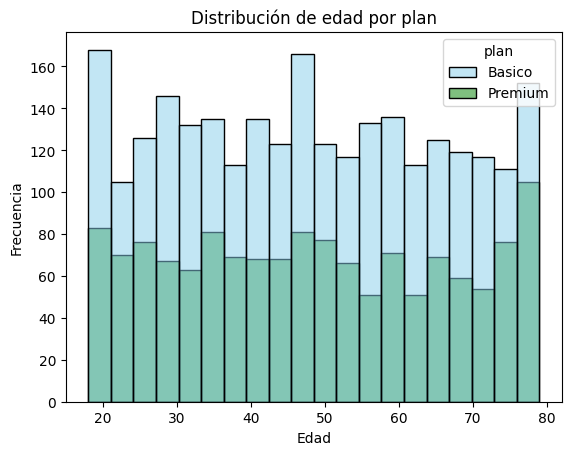

In [40]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **EDAD:** La distribución de edad es relativamente uniforme entre los planes, sin diferencias marcadas, lo que sugiere que ambos planes son utilizados por usuarios de distintos rangos de edad.

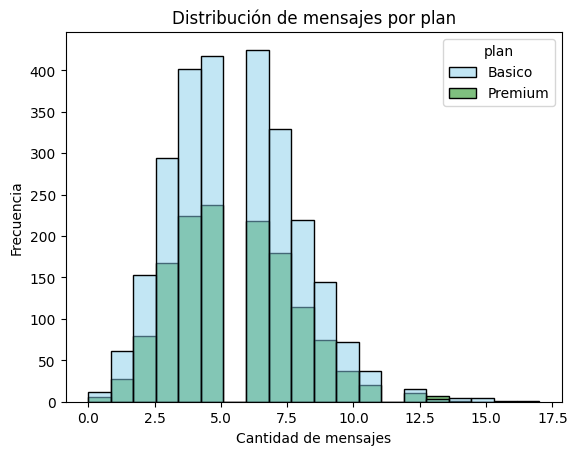

In [41]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **MENSAJES:** Se observa que la mayoría de los usuarios envía pocos mensajes, con una distribución sesgada a la derecha. No se evidencian diferencias significativas entre los planes.

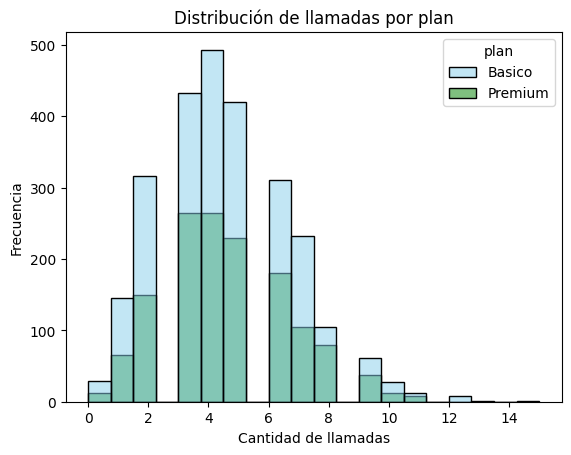

In [42]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **LLAMADAS** La cantidad de llamadas presenta variabilidad entre usuarios, con una distribución también sesgada a la derecha. Algunos usuarios realizan muchas más llamadas que la mayoría.

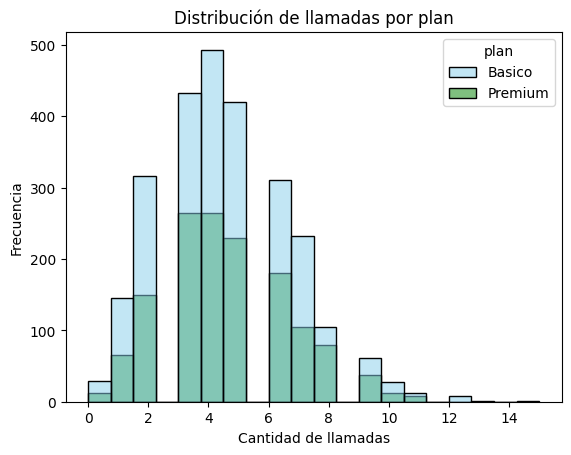

In [43]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], bins=20)
plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- **MINUTOS** Los minutos de llamada muestran una distribución sesgada a la derecha, indicando que pocos usuarios concentran un alto consumo. Puede haber presencia de valores extremos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

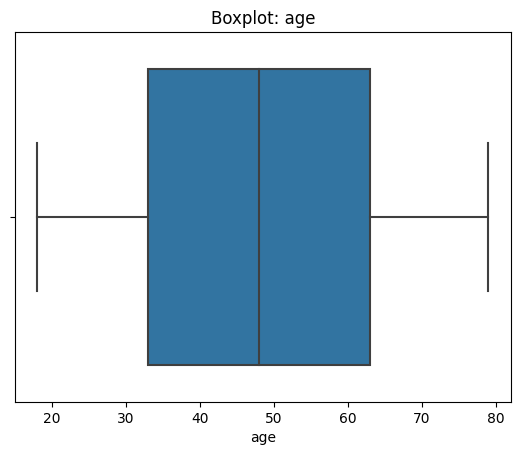

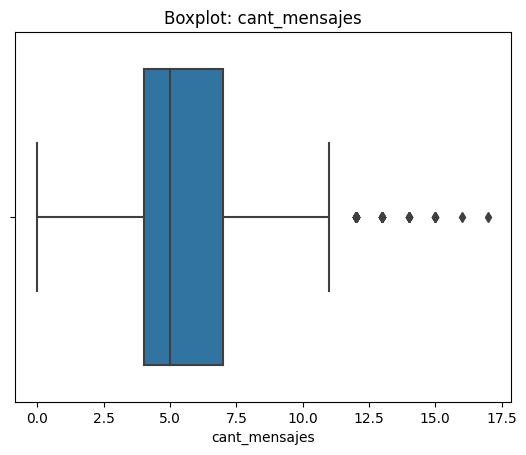

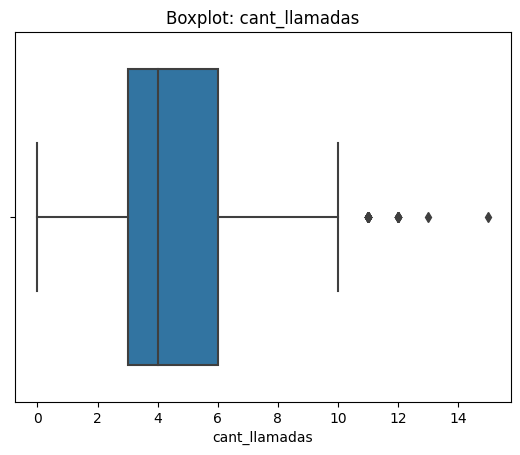

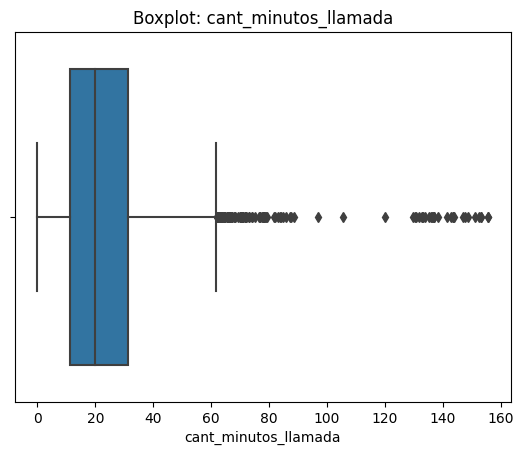

In [44]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure()
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No se observan valores atípicos relevantes. La distribución de edades se encuentra dentro de un rango esperado, por lo que no se identifican problemas en esta variable.
- cant_mensajes: Se identifican algunos valores atípicos hacia el extremo superior, lo que indica que algunos usuarios envían una cantidad de mensajes mayor que la mayoría. Estos casos pueden corresponder a usuarios con mayor actividad.
- cant_llamadas: Se observan valores atípicos en el extremo superior, lo que sugiere que algunos usuarios realizan más llamadas que el promedio. No parecen ser errores, sino comportamientos de uso intensivo.
- cant_minutos_llamada: Se identifican varios valores atípicos altos, evidenciando que algunos usuarios concentran un consumo elevado de minutos. Estos outliers probablemente representan usuarios con alto uso del servicio.

In [45]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_sup = Q3 + 1.5 * IQR
    max_val = user_profile[col].max()

    print(f'Columna: {col}')
    print(f'Límite superior: {limite_sup}')
    print(f'Máximo: {max_val}')
    print('---')

Columna: cant_mensajes
Límite superior: 11.5
Máximo: 17.0
---
Columna: cant_llamadas
Límite superior: 10.5
Máximo: 15.0
---
Columna: cant_minutos_llamada
Límite superior: 61.8575
Máximo: 155.69
---


In [46]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: Se mantienen los outliers, ya que los valores son posibles y representan usuarios con mayor uso de mensajes.
- cant_llamadas: Se mantienen los outliers porque corresponden a usuarios que realizan más llamadas de lo habitual y no indican errores.
- cant_minutos_llamada: Se mantienen los outliers, ya que reflejan usuarios con alto consumo de minutos y son coherentes con el comportamiento esperado.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [47]:
# Crear columna grupo_uso
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

opciones = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

In [48]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [49]:
# Crear columna grupo_edad
condiciones = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

opciones = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, opciones, default='Adulto Mayor')

In [50]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

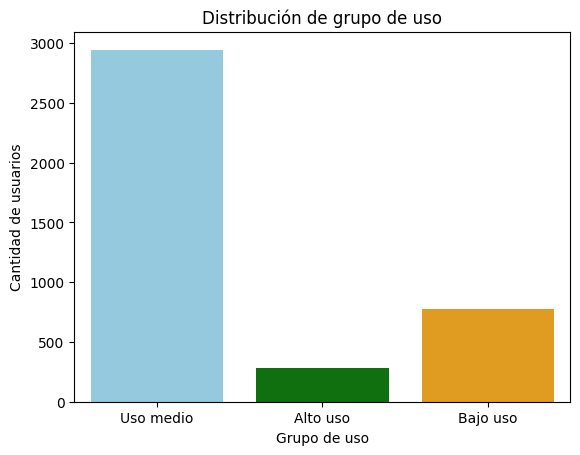

In [51]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

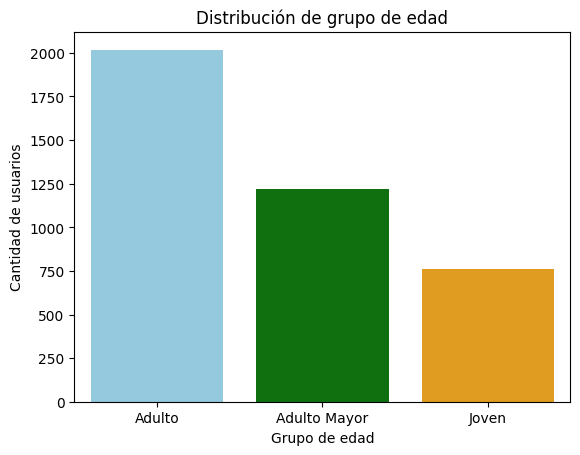

In [52]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se identificaron valores inválidos en la edad (-999), registros inconsistentes en la ciudad (”?”) y fechas fuera de rango (2026).
-  casos fueron corregidos sin afectar de manera significativa el volumen total de datos.

🔍 **Segmentos por Edad**
- La mayoría de los usuarios se concentra en edades adultas, con menor presencia de jóvenes y adultos mayores.
- Esto puede explicarse porque los adultos tienen mayor capacidad de pago y necesidad de comunicación. Además, los jóvenes utilizan más aplicaciones y datos móviles, lo cual no se refleja completamente en las métricas analizadas.


📊 **Segmentos por Nivel de Uso**
- Predominan los usuarios con niveles de uso bajo y medio, mientras que un grupo reducido presenta un uso intensivo.
- Los usuarios de alto uso concentran mayor actividad en llamadas y mensajes

➡️ Esto sugiere que ...
- Existe un segmento de usuarios intensivos que representa una oportunidad clave de valor para la empresa.
- El comportamiento de uso varía según el perfil del usuario, especialmente por edad y nivel de consumo.

💡 **Recomendaciones**
- Ajustar la oferta de planes según el nivel de uso, creando opciones específicas para usuarios intensivos.
- Diseñar estrategias para incentivar mayor consumo en usuarios de bajo uso.
- Considerar la edad como variable clave para segmentar mejor la oferta y personalizar beneficios.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`